In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from scipy.linalg import eig, eigvals
import scipy.sparse.linalg as sc
from scipy.integrate import ode, solve_ivp
from scipy.interpolate import PchipInterpolator

In [23]:
def dip_norm(phir,phid):
    return 1-3*(np.cos(phir-phid))**2

def dip_first_der_norm(phir,phid):
    return -3*np.cos(phir)+15*np.cos(phir)*np.cos(phir-phid)**2-6*np.cos(phid)*np.cos(phir-phid)

def dip_second_der_norm(phir,phid):
    return -3+15*np.cos(phir-phid)**2-6*np.cos(phid)**2+\
        60*np.cos(phir)*np.cos(phid)*np.cos(phir-phid)+15*np.cos(phir)**2*(1-7*np.cos(phir-phid)**2)

def nom_der1(DelR,d):

    rx = DelR[0]/np.linalg.norm(DelR)
    ry = DelR[1]/np.linalg.norm(DelR)
    
    f = -3*rx + 15*rx*(rx*d[0]+ry*d[1])**2-6*d[0]*(rx*d[0]+ry*d[1])
    return f/np.linalg.norm(DelR)**4

def dip_derivative_full(Delta_R_vec: np.ndarray, i: int, j: int, d: np.ndarray,interaction_radius=None) -> float:
    Del_R = np.linalg.norm(Delta_R_vec)

    if Del_R==0:
        return 0
    elif interaction_radius and Del_R > interaction_radius + 0.01:
        return 0
    potential = 0

    if i == j:
        potential += 3/ Del_R**5-15*np.dot(d,Delta_R_vec)**2/Del_R**7
    potential += 6/ Del_R**5*d[i]*d[j]
    potential -= 30*(d[i]*Delta_R_vec[j]+d[j]*Delta_R_vec[i])*np.dot(d,Delta_R_vec)/Del_R**7
    potential -= 15*Delta_R_vec[i]*Delta_R_vec[j]*(1/Del_R**7-7*np.dot(d,Delta_R_vec)**2/Del_R**9)
    # return Del_R
    return potential

def dip_dip(r_vec,d):
    r = np.linalg.norm(r_vec)
    if r==0:
        return 0
    potential = 1/r**3 * (1- 3*(np.dot(d,r_vec)/r)**2)
    return potential

# def nom_der1(dx,phi):
#     rx = np.cos(phi)
#     ry = np.sin(phi)
#     dy = np.sqrt(1-dx**2)
#     f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
#     return f

def dip_zero_der(b,h):
    phi = np.arctan(h/b)
    bracket = (max(-1,0-phi/2*2.8),max(0,0.7-phi/2))
    # bracket = (0,1)
    if nom_der1(bracket[0],phi)*nom_der1(bracket[1],phi)<=0:
        root = root_scalar(nom_der1,args=phi,bracket=bracket)
        # root = root_scalar(func,args=phi,x0=0)
        return root.root
    return 0 


def dipole_trap_onsite(i: int, j:int) -> float:
    if i==j:
        return 1
    else:
        return 0

def max_phi(r):
    return min(np.arccos((np.sqrt(1+2*r**2)-1)/2/r),np.arccos((r-1)/r))

def d_1(a,e):
    d = 0.9
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    A = 12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9)
    B = 15*(a*e/r1**7-e/r2**7)
    res =  B**2*(1-d**2)/(A**2*d**2+B**2*(1-d**2))
    return np.array([np.sqrt(res),np.where(A*B>=0,1,-1)*np.sqrt(1-res)])

def interaction_rotated(DelR,i,j,interaction_radius,d1):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    d2 =0.9
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0

    if i==j:
        B = -3/r**5+15*DelR[i]**2/r**7
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        return A*d1[0]*d2 - B*d1[1]*np.sqrt(1-d2**2)
    else:
        A = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        B = 15 *DelR[0]*DelR[1]/r**7
        return d1[0]*d2*A-B*d1[1]*np.sqrt(1-d2**2)
    

def phi_1(a,e):
    r1 = np.sqrt(a**2+e**2)
    r2 = np.sqrt(1+e**2)
    B = (12*(1/r1**5+1/r2**5)-7*15*(a**2*e**2/r1**9+e**2/r2**9))*(-1)
    A = 45*(a*e/r1**7-e/r2**7)-7*15*(a**3*e/r1**9-e/r2**9)
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane(a,e):
    d = 0.7
    phi = phi_1(a,e)
    return d*np.array([np.cos(phi),np.sin(phi)])

def phi_2(r,phi):
    B  = (-1)*(24/r**5-7*15*np.cos(phi)**2*np.sin(phi)**2/r**5)
    A = 45*np.cos(phi)*np.sin(phi)/r**5-7*15*np.cos(phi)**3*np.sin(phi)/r**5
    res =  np.arctan(A/B)+np.where(B>=0,1,-1)*np.pi*(1-np.where(B>=0,1,-1))/2
    return res

def d_plane_2(r,phi):
    d = 0.7
    phi_d = phi_2(r,phi)
    return d*np.array([np.cos(phi_d),np.sin(phi_d)])

def interaction_dipplain(DelR,i,j,interaction_radius,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    
    
    if i==j:
        A = -3/r**5+15*(DelR[0]**2+DelR[i]*DelR[0]*2+ DelR[i]**2)/r**7-7*15*DelR[0]**2*DelR[i]**2/r**9
        B = 15*DelR[0]*DelR[1]/r**7-7*15*DelR[0]*DelR[1]*DelR[i]**2/r**9
        if i==0:
            A += 15*2*DelR[0]**2/r**7-6/r**5
            B += 30*DelR[0]*DelR[1]/r**7
        return A*d[0] + B*d[1]
    else:
        B = 12/r**5-7*15*DelR[0]**2*DelR[1]**2/r**9
        A = 45*DelR[0]*DelR[1]/r**7-7*15*DelR[0]**3*DelR[1]/r**9
        return A*d[0] + B*d[1]  
    
def max_b(h,a):
    return np.sqrt((a-0.011)**2-h**2)

def Vxy_decomp(x,y):
    r = np.sqrt(x**2+y**2)
    A = 24/r**5-7*30*x**2*y**2/r**9
    C = 45*x*y/r**7
    B = -7*15*x**3*y/r**9
    D = -7*15*x*y**3/r**9
    return np.array([A, B, C, D])

def Vxy(DelR,d):
    A, B, C, D = Vxy_decomp(DelR[0],DelR[1])
    return A*d[0]*d[1]+C+B*d[0]**2+D*d[1]**2

def Vaa(DelR,i,d):
    r = np.sqrt(DelR[0]**2+DelR[1]**2)
    A = -3/r**5+15*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**7
    B = -6*d[i]**2/r**5+30*(2*d[i]*DelR[i]*(DelR[0]*d[0]+DelR[1]*d[1]))/r**7
    C = 15*(DelR[i]**2/r**7-7*DelR[i]**2*(DelR[0]**2*d[0]**2+DelR[1]**2*d[1]**2+2*DelR[0]*DelR[1]*d[0]*d[1])/r**9)
    return A+B+C

def interaction_aligned_dip(DelR,i,j,interaction_radius,beta,d):
    r = np.linalg.norm(DelR)
    
    if r ==0:
        return 0
    if r>interaction_radius+0.01:
        return 0
    if i==j:
        return Vaa(DelR,i,d)*beta
    else:
        return Vxy(DelR,d)*beta


def d_aligned(b,h,a):
    A, B, C, D = Vxy_decomp(b,h)+Vxy_decomp(b-a,h)
    a = (D-B)**2+A**2
    bi = -(A**2+2*(C+D)*(D-B))
    c = (C+D)**2
    sq = np.sqrt(bi**2-4*a*c)
    ot = -bi
    dx = np.sqrt((ot+sq)/2/a)
    sign = np.where((-(C+D)+(D-B)*dx**2)*A>=0,1,-1)
    return np.array([dx,np.sqrt(1-dx**2)*sign])



In [3]:
class TickProperties():
    
    major_xtick_step = 5,
    minor_xtick_step = 1
    major_ytick_step = 5
    minor_ytick_step = 1
    STRIP_OF_ZEROS_X = False
    STRIP_OF_ZEROS_Y = False

    def __init__(self,\
    xtick_step_major = 5,\
    xtick_step_minor = 1,\
    ytick_step_major = 5,\
    ytick_step_minor = 1,\
    SZX = False,\
    SZY = False):
        self.major_xtick_step = xtick_step_major
        self.minor_xtick_step = xtick_step_minor
        self.major_ytick_step = ytick_step_major
        self.minor_ytick_step = ytick_step_minor
        self.STRIP_OF_ZEROS_X = SZX
        self.STRIP_OF_ZEROS_Y = SZY

class Format():
    numb_xticks = None
    numb_yticks = None
    custom_func_x = None
    custom_func_y = None
    x_scale = None
    y_scale = None
    x_precion = "{:.2f}"
    y_precion = "{:.2f}"
    def __init__(self,numb_xticks=None,numb_yticks=None,custom_funx=None,custom_funy=None,xscale=None,yscale=None,xprec="{:.2f}",yprec="{:.2f}"):
        self.numb_xticks =numb_xticks
        self.numb_yticks = numb_yticks
        self.custom_func_x = custom_funx
        self.custom_func_y = custom_funy
        self.x_precion=xprec
        self.y_precion = yprec
        self.x_scale = xscale
        self.y_scale = yscale
    def formatx0(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            # print(x,pos,self.numb_xticks)
            index = int((pos-1)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print(self.x_precion.format(self.x_scale[index]))
            return self.x_precion.format(self.x_scale[index])
        except:
            # print(self.x_precion.format(self.x_scale[-1]))
            return self.x_precion.format(self.x_scale[-1])
    def formatx1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))
            print(pos)
            index = int((pos)*self.x_scale.shape[0]//self.numb_xticks)
            # print(index)
            # print()
            return self.x_precion.format(self.x_scale[index])
        except:
            return self.x_precion.format(self.x_scale[-1])
    
    def formaty1(self,x,pos):
        try:
                # print(x,pos)#,"{:.2f}".format(w[int(x)]))

            index = int((pos-1)*self.y_scale.shape[0]//self.numb_yticks)
            # print(index)
            # print()
            return self.y_precion.format(self.y_scale[index])
        except:
            return self.y_precion.format(self.y_scale[-1])
        
    def formaty(self,x,pos):
        try:
            return self.y_precion.format(self.y_scale[int(x)])
        except:
            return ""

class Setup_Fig():
    DEFAULT_HEAT_EXTEND = (-0.5,39.5,29.5,-0.5)
    xlim = None
    ylim = None
    tickprop = TickProperties()
    formatter = Format()
    cm = 1/2.54 
    fig_width = 12*cm
    fig_height = 4.8/6.4*12*cm
    name_of_plot = None
    xax_share = None
    yax_share = None
    joined= None
    def __init__(self,name_of_plot = "sign_of_ev1.pdf",xlim=None,ylim=None,tickp=TickProperties(),formater=Format(),xax_share = False, yax_share = False, joined= False,fig_width = 12*cm,fig_height = 4.8/6.4*12*cm):
        self.xlim=xlim
        self.ylim = ylim   
        self.tickprop =tickp       
        self.formatter = formater
        self.name_of_plot = name_of_plot
        self.xax_share = xax_share 
        self.yax_share = yax_share 
        self.joined = joined
        self.fig_height = fig_height
        self.fig_width = fig_width


    
    plt.rcParams["lines.markersize"]=0.7
    plt.rcParams["axes.unicode_minus"]=True
    plt.rcParams["font.size"]=10
    plt.rcParams["text.usetex"]=True
    plt.rcParams["font.serif"]="Computer Modern Serif"
# ax.scatter(A,root,color='0')
    



    def return_fig(self,shape=(1,1),dots_per_inch=400,heightratio=None):
        if heightratio:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share,height_ratios=heightratio)
        else:
            fig, ax = plt.subplots(*shape,figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch,sharex=self.xax_share,sharey=self.yax_share)
        # trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        # self.formatter.numb_xticks = xw//self.tickprop.major_xtick_step
        # self.formatter.numb_yticks = yw//self.tickprop.major_ytick_step
        return fig, ax
    
    def return_gridspec(self,shape=(1,1),dots_per_inch=400):
        fig = plt.figure(figsize=(self.fig_width,self.fig_height),dpi=dots_per_inch)
        gs = gridspec.GridSpec(*shape, figure=fig)
        if shape[0]==1 or shape[1]==1:
            num = max(shape)
            axes = np.empty((num),dtype=object)
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i+j] = fig.add_subplot(gs[i,j])
        else:
            axes = np.empty(shape,dtype=object)
            # axes = []
            for i in range(shape[0]):
                for j in range(shape[1]):
                    axes[i,j] =  fig.add_subplot(gs[i,j])
                    # axes.append(fig.add_subplot(gs[i,j]))
                # axes[-1].set_aspect('auto')
        return fig, axes

        
    def format_ax(self,current_ax,shape,tickprop=None,j=0,bottom=True,set_ticks=True):
        # print(f"format_ax called with j={j}, shape={shape}")
        trash, xw, yw, trash=self.DEFAULT_HEAT_EXTEND# im.get_extent()
        self.formatter.numb_xticks = (xw+0.5)//self.tickprop.major_xtick_step
        self.formatter.numb_yticks = (yw+0.5)//self.tickprop.major_ytick_step
        pos= 'outer_left'
        current_ax.set_aspect('auto')
        if shape[1]>1:
                if j==0:
                    pos= 'outer_left'
                elif j<shape[1]-1 or j==-1:
                    pos = 'middle'
                elif j==shape[1]-1:
                    pos = 'outer_right'
                


        # axlimits have to be adapted
        try:
            current_ax.set_xlim(*self.xlim)
        except:
            pass
        try:
            current_ax.set_ylim(*self.ylim)
        except:
            pass    
    
        if set_ticks:
            if tickprop.STRIP_OF_ZEROS_X:
                current_ax.xaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formatx0))
            current_ax.yaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_ytick_step))
            current_ax.yaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_ytick_step))
            current_ax.xaxis.set_major_locator(ticker.MultipleLocator(tickprop.major_xtick_step))
            current_ax.xaxis.set_minor_locator(ticker.MultipleLocator(tickprop.minor_xtick_step))

            if tickprop.STRIP_OF_ZEROS_Y:
                current_ax.yaxis.set_major_formatter(ticker.FuncFormatter(self.formatter.formaty1))  

        if self.joined:
            
            if not bottom:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=False)
            else:
                current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
                
            if pos=='outer_left':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)
            elif pos=='middle':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=False)
            elif pos=='outer_right':
                current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelright=True,labelleft=False)
                current_ax.yaxis.set_label_position("right")
                # current_ax.set_xlabel(r'$\Gamma \tilde{A}$')
                # current_ax.set_ylabel(r'$\tilde{y}$',rotation=0)
        else:
            current_ax.tick_params(axis='x',direction='in',which='both',bottom=True,top=True,labelbottom=True)
            
            current_ax.tick_params(axis='y',direction='in',which='both',left=True,right=True,labelleft=True)   


        current_ax.tick_params(axis='both',which='major',length=4.5)
        plt.setp(current_ax.yaxis.get_majorticklabels(),va='center')
        
        return current_ax

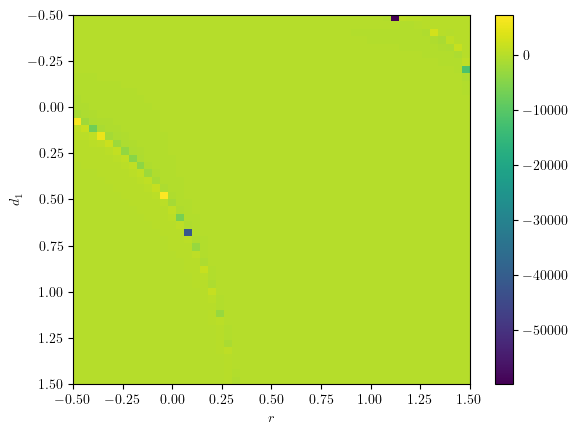

In [4]:
N = 50
h = 0.2
def max_der(R,d):
    items = []
    for i in range(2):
        for j in range(2):
            items.append(np.abs(dip_derivative_full(R,i,j,d,100)))
    return items[0]#max(items)
R = np.stack((np.linspace(0,1,N),np.ones(N)*h))
d1 = np.linspace(0,1,N)
d = np.array([np.sqrt(1/3),np.sqrt(2/3)])

V = np.zeros((N,N))
V_der = np.zeros((N,N))
for i in range(N):#
    for j in range(N):
        V[i,j] = dip_dip(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))
        V_der[i,j] = max_der(R[:,i],np.array([d1[j],np.sqrt(1-d1[j]**2)]))

fig, ax = plt.subplots(1,1)
im = ax.imshow(V_der/V,extent=(-0.5,1.5,1.5,-0.5),aspect='auto')
ax.set_xlabel(r'$r$')
ax.set_ylabel(r'$d_1$')
plt.colorbar(im,ax=ax)
plt.show()

# fig, ax = plt.subplots(1,2)
# for i in range(N):#
#     ax[0].scatter(R[0,i],max_der(R[:,i],d)/dip_dip(R[:,i],d),color='0')
#     ax[1].scatter(R[0,i],dip_dip(R[:,i],d),color='0')
# plt.show()


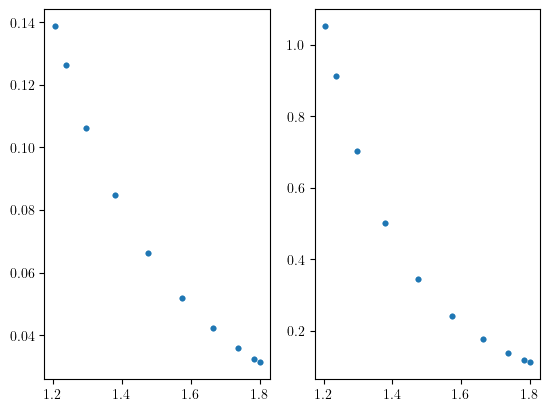

In [5]:
from scipy.optimize import minimize, root_scalar
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))
b0 =1.8
a = 3
freq = 1
h = 0.4
N = 20
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d= np.array([0,1])
def time_traj(t):
    b = a/2+(b0-a/2)*np.cos(2*np.pi*freq*t)
    Delta = np.sin(2*np.pi*freq*t)
    dx = dip_zero_der(b,h)
    d = np.array([dx,np.sqrt(1-dx**2)])
    return b, h, Delta, d
rx = np.linspace(0.5,4,N)
t = np.linspace(0,1,N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
Delta = np.zeros(N)
for i in range(N):
    rx[i], h, Delta[i], d = time_traj(t[i])
    V_der[i] = dip_derivative_full(np.array([rx[i],h]),0,0,d,100)
    V[i] = dip_dip(np.array([rx[i],h]),d)
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),d)
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,d,100)
    


# fig, ax = plt.subplots(2,2,figsize=(6,5))
# # ax[0].scatter(rx,opt_h)
# # ax[0].scatter(rx,opt_d1)
# ax[0,0].scatter(t,V)
# ax[0,1].scatter(t,V_der)
# ax[1,0].scatter(rx,V)
# ax[1,1].scatter(rx,V_der)
# ax[0,0].set_xlabel(r'$t$')
# ax[0,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
# ax[0,1].set_xlabel(r'$t$')
# ax[0,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
# ax[1,0].set_xlabel(r'$b$')
# ax[1,0].set_ylabel(r'$V_\text{dip}$',rotation=0)
# ax[1,1].set_xlabel(r'$b$')
# ax[1,1].set_ylabel(r'$V_\text{cpl.}$',rotation=0,labelpad=10)
# plt.subplots_adjust(wspace=0.4,hspace=0.3)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V,s=10)
ax2[1].scatter(rx,V_der,s=10)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"interaction_ricemele_chain4.pdf")
plt.show()





In [6]:
V_der[0], V[0]

(np.float64(0.11303015793764848), np.float64(0.031389654127400045))

In [7]:
h = 0.4
a = 2
b = 1.8#a/2
# d = np.array([0,1])
dx = dip_zero_der(b,h)
d = np.array([dx,np.sqrt(1-dx**2)])
dip_derivative_full(np.array([b,h]),0,0,d,100),  dip_dip(np.array([b,h]),d)

(np.float64(0.11303015793764848), np.float64(0.031389654127400045))

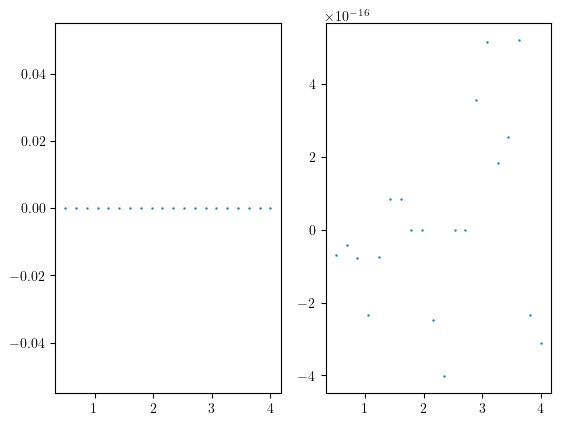

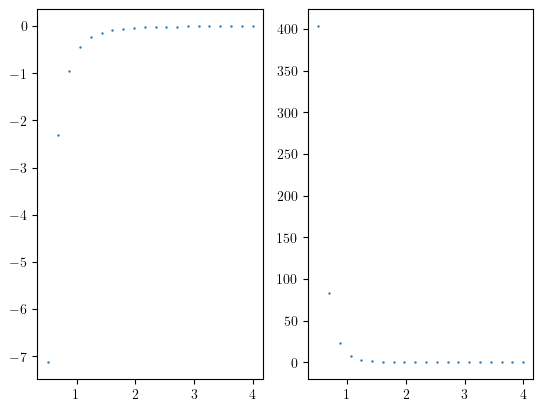

In [8]:
from scipy.optimize import minimize
def ratio(x,rx):
    h = x[0]
    d = np.array([np.sin(x[1]),np.cos(x[1])])
    R = np.array([rx,h])
    return -np.abs(dip_derivative_full(R,0,0,d,100)/dip_dip(R,d))

rx = np.linspace(0.5,4,N)
opt_h = np.ones(N)
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    res = minimize(ratio,x0=[opt_h[i-1],opt_d1[i-1]],args=(rx[i],),bounds=((0.15,1),(0,np.pi)))
    opt_h[i] = 0.2
    opt_d1[i] = np.arcsin(np.sqrt(1/3))
    opt_ratio[i] = res.fun
    V_der[i] = dip_derivative_full(np.array([rx[i],opt_h[i]]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)
    V[i] = dip_dip(np.array([rx[i],opt_h[i]]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V2[i] = dip_dip(np.array([rx[i]*4/3,0]),np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]))
    V_der2[i] = dip_derivative_full(np.array([rx[i]*4/3,0]),0,0,np.array([np.sin(opt_d1[i]),np.cos(opt_d1[i])]),100)


fig, ax = plt.subplots(1,2)
# ax[0].scatter(rx,opt_h)
# ax[0].scatter(rx,opt_d1)
ax[0].scatter(rx,V2/V)
ax[1].scatter(rx,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(rx,V)
ax2[1].scatter(rx,V_der)
plt.show()





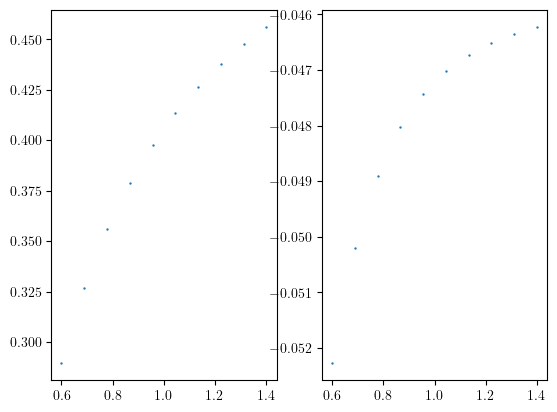

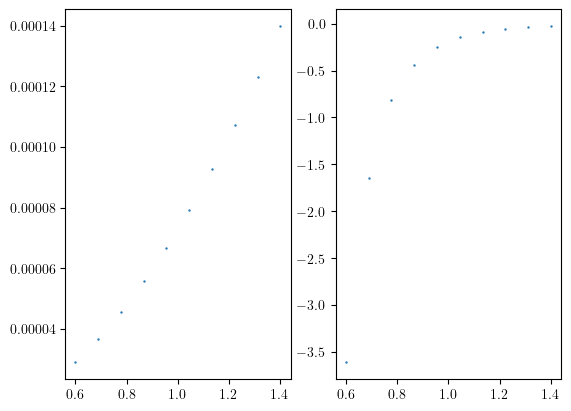

In [9]:
from scipy.optimize import root_scalar, minimize_scalar
def null(dx,R,sign):
    a = R[0]
    h = R[1]
    return 3*(a**2*dx**2+h**2*(1-dx**2)+sign*2*a*h*dx*np.sqrt(1-dx**2))-(a**2+h**2)
h = 0.35
N = 10
def ratio(h,rx):
    r = root_scalar(null,args=(np.array([rx,h]),1),bracket=(0,1))
    d = np.array([r.root,np.sqrt(1-r.root**2)])
    return np.abs(dip_derivative_full(np.array([rx,h]),0,0,d,100)/dip_derivative_full(np.array([rx*2,0]),0,0,d,100))
x = np.linspace(0.6,1.4,N)
opt_h = np.ones(N)*0.2
opt_d1 = np.ones(N)
opt_ratio = np.zeros(N)
V = np.zeros(N)
V2 = np.zeros(N)
V_der = np.zeros(N)
V_der2 = np.zeros(N)
for i in range(N):
    # res = minimize_scalar(ratio,args=(x[i],),bounds=((0.2,0.35)))
    opt_h[i] = 0.2#res.x
    r = root_scalar(null,args=(np.array([x[i],opt_h[i]]),1),bracket=(0,1))
    # r2 = root_scalar(null,args=(np.array([x[i],h]),-1),bracket=(0,1))
    opt_d1[i] = r.root
    V[i] = dip_dip(np.array([4*3*x[i],0]),np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]))
   
    V_der[i] = dip_derivative_full(np.array([x[i],opt_h[i]]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)
    V_der2[i] = dip_derivative_full(np.array([x[i]*2,0]),0,0,np.array([opt_d1[i],np.sqrt(1-opt_d1[i]**2)]),100)

fig, ax = plt.subplots(1,2)
# ax[0].scatter(x,opt_h)
ax[0].scatter(x,opt_d1)
# ax[0].scatter(x,opt_ratio)
ax[1].scatter(x,V_der2/V_der)
fig2, ax2 = plt.subplots(1,2)
ax2[0].scatter(x,V/V_der)
ax2[1].scatter(x,V_der2)
plt.show()



In [10]:
import scipy.constants as c

a0 = 4*np.pi*c.epsilon_0*c.hbar**2/(c.m_e*c.e**2)
d = np.array([1000,5000])*c.e*a0
r0 = np.array([10,3])/10**6
V = d**2/(4*np.pi*c.epsilon_0*r0**5)
V#/c.hbar

array([6.46047512e-18, 6.64657935e-14])

In [161]:
m = 85.5*c.u
w = 2*np.pi*10**3*np.array([50,80])
r= np.array([3,10])/10**6
np.sqrt(c.hbar/m/2/w)/r, np.sqrt(c.hbar/2/m/w)
# m*w**2*r**2/V[::-1]

(array([0.01146091, 0.00271819]), array([3.43827445e-08, 2.71819462e-08]))

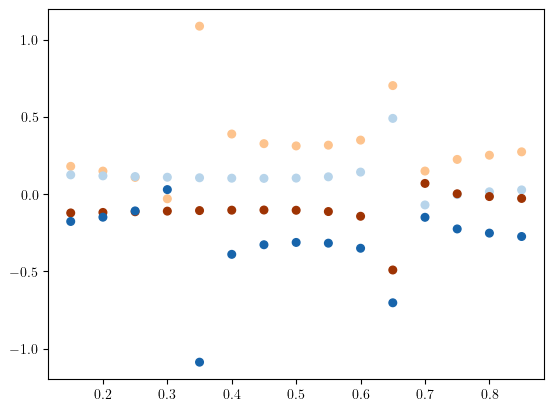

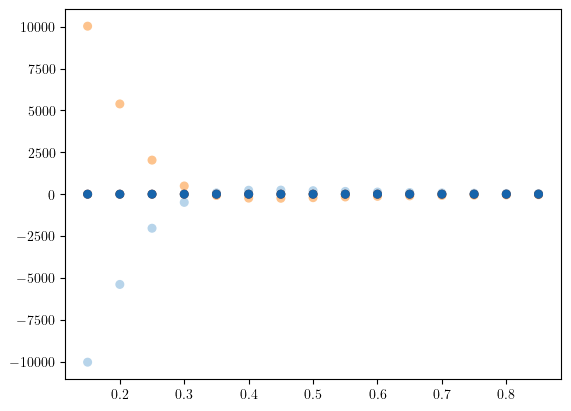

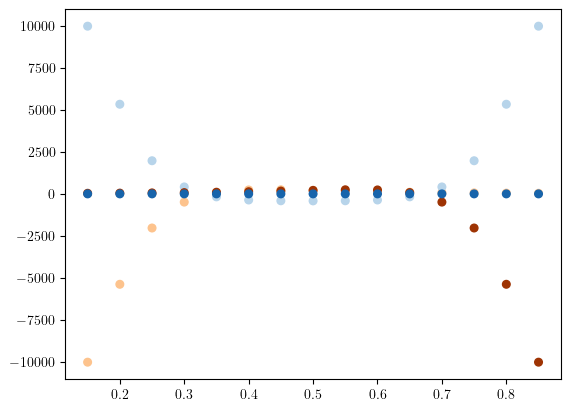

In [110]:
def grad(b,h,a,chain_length,interaction,d):
    latticeA = np.array([[0,0],[a,0]])
    latticeB = np.array([b,h])
    dist1 = latticeB-latticeA[0]
    dist2 = latticeA[1]-latticeB
    grad1 = interaction(dist1,d)
    grad2 = interaction(dist2,d)
    grad_vec = np.zeros(chain_length)
    # print(grad1,grad2)
    grad_vec[0] = -grad1
    grad_vec[1:-1] = -grad2+grad1
    grad_vec[-1] = grad1-(grad1-grad2)*(chain_length%2)
    grad_vec[1:-1] *= (-1)**np.arange(chain_length-2)
    return grad_vec
    return grad1, grad2
    return dist1, dist2

def nearest_nb_Hamiltonian(b,h,a,chain_length,interaction,Delta,d):
    latticeA = np.zeros((2,chain_length//2+chain_length%2))
    latticeB = np.zeros((2,chain_length//2))
    for n in range(latticeA.shape[1]):
        latticeA[:,n] = n*np.array([1,0])*a
    for n in range(latticeB.shape[1]):
        latticeB[:,n] = n*np.array([1,0])*a + b * np.array([1,0])+h*np.array([0,1])
    dmat = np.zeros((chain_length,chain_length))
    ind = np.arange(chain_length,dtype=np.int16)
    inter_1 = interaction(latticeB[:,0]-latticeA[:,0],d)
    inter_2 = interaction(latticeB[:,0]-latticeA[:,1],d)
    dmat[ind[:-1:2],ind[1::2]]= inter_1
    dmat[ind[1::2],ind[:-1:2]]= inter_1
    dmat[ind[1:-1:2],ind[2::2]] = inter_2
    dmat[ind[2::2],ind[1:-1:2]] = inter_2
    dmat[0,0] = -inter_1
    dmat[-1,-1] = -inter_1-(inter_2-inter_1)*(chain_length%2)
    dmat[ind[1:-1],ind[1:-1]] = -inter_1-inter_2 
    # dmat[ind[2:-1:2],ind[2:-1:2]]= -Delta
    # print(inter_1,inter_2,b)
    return dmat#


import matplotlib.cm as cm
orange = cm.Oranges
blue = cm.Blues
chain_length = 4
N = 15
# b = np.linspace(0.465,0.535,N)
b = np.linspace(0.15,0.85,N)
h = 0.2
a = 1
# d = np.array([np.sqrt(1/3),np.sqrt(2/3)])
d = np.array([1,0])
eigenvecs = np.zeros((N,chain_length))
dist1 = np.zeros(N)
dist2 = np.zeros(N)
fig, ax = plt.subplots(1,1)
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,1)
colors = np.zeros((chain_length,4))
colors[::2] = orange(np.linspace(0.3,0.9,chain_length//2+chain_length%2))
colors[1::2] = blue(np.linspace(0.3,0.8,chain_length//2))
for i in range(N):
    dmat = nearest_nb_Hamiltonian(b[i],h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b[i],h,a,chain_length,nom_der1,d)
    # eig, vecs = np.linalg.eig(dmat)
    # eigenvecs[i,:] = sorted(eig)
    eigenvecs[i,:] = np.linalg.solve(dmat,beta)
    # ax.scatter(b[i]*np.ones(chain_length-2),beta[::3],color='0')
    # ax.scatter(b[i]*np.ones(chain_length-2),eigenvecs[i,2:],color=colors[:2],s=30)
    ax.scatter(b[i]*np.ones(chain_length),eigenvecs[i,:],color=colors,s=30)
    # dist1[i], dist2[i] = grad(b[i],h,a,chain_length,nom_der1,d)
    # ax.scatter(b[i]*np.ones(chain_length),beta,color='0')
    ax2.scatter(b[i]*np.ones(chain_length),dmat[:,0],color=colors,s=30)
    ax3.scatter(b[i]*np.ones(chain_length),dmat[:,1],color=colors,s=30)
    # ax.scatter(b[i]*np.ones(1),dist1,color='0')
    # ax.scatter(b[i]*np.ones(1),dist2,color='red')
# ax.scatter(b,dist1,color='0')
# ax.scatter(b,dist2[::-1],color='red')
# ax.set_ylim(-3,3)
plt.show()


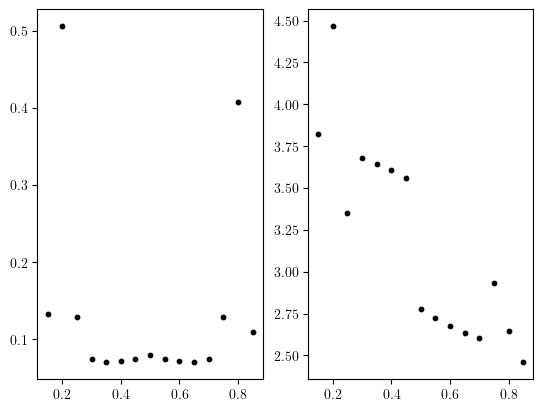

In [120]:
chain_length = 8
def abs_eigvec(phid,b):
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize_scalar
b = np.linspace(0.15,0.85,N)
fig, ax = plt.subplots(1,2)
for i in range(N):
    res = minimize_scalar(abs_eigvec,args=b[i],bounds=(0,2*np.pi),method='bounded')
    ax[0].scatter(b[i],res.fun,color='0',s=10)
    ax[1].scatter(b[i],res.x,color='0',s=10)
plt.show()
    

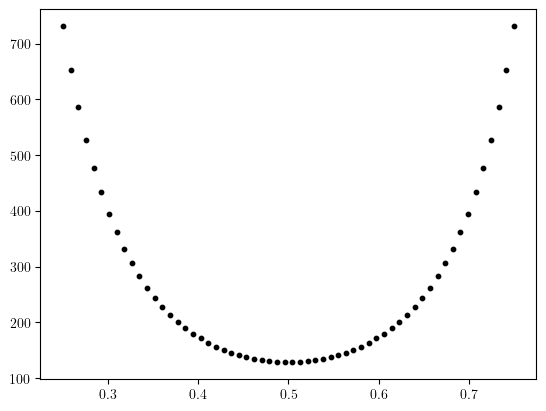

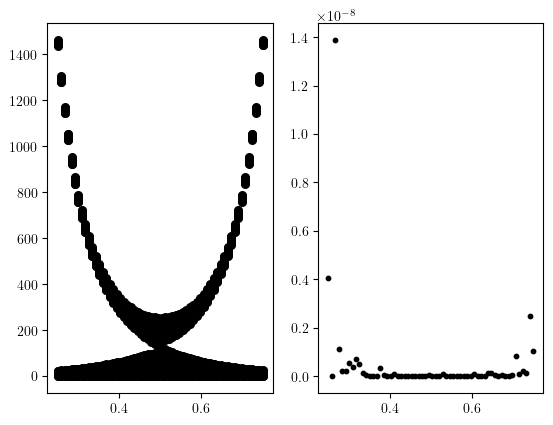

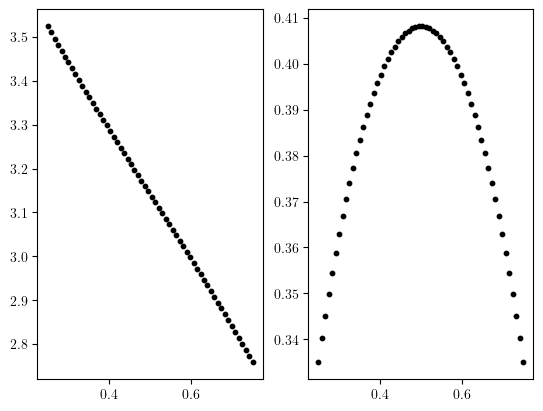

In [171]:
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    eigenvecs = np.linalg.solve(dmat,beta)
    # eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis = np.ones(N)*(3.7)
hs = np.ones(N)*0.25
fig2, ax2 = plt.subplots(1,1)
fig3, ax3 = plt.subplots(1,2)
fig, ax = plt.subplots(1,2)
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    min_vals = np.zeros((len(phi_grid),len(h_grid)))
    min_phi = np.zeros_like(min_vals)
    min_h = np.zeros_like(min_vals)
    min_vals = []
    min_phi = []
    min_h = []
    phi_grid = np.linspace(-Deltap,Deltap,10)+phis[i-1]
    h_grid = np.linspace(-Deltah,Deltah,10)+hs[i-1]
    for n in range(len(phi_grid)):
        for m in range(len(h_grid)):
            try:
                res = minimize(abs_eigvec,x0=(phi_grid[n],h_grid[m]),args=b[i],bounds=((0,2*np.pi),(-0.5,0.5)),tol=1e-12)
                min_vals.append(res.fun)
                min_phi.append(res.x[0])
                min_h.append(res.x[1])
            except:
                pass
    crit = np.array([min_vals, min_phi, min_h]).T
    sorted_crit = sorted(crit, key=lambda x: x[0])
    

    phis[i] = sorted_crit[0][1]
    hs[i] = sorted_crit[0][2]
    dmat = nearest_nb_Hamiltonian(b[i],hs[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    eig, vec = np.linalg.eig(dmat)
    ax3[0].scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs[i],a,chain_length,nom_der1,np.array([np.cos(phis[i]),np.sin(phis[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    vecp = np.linalg.solve(dmatp,beta)
    dis = dmat@vecp
    ax3[1].scatter(b[i],np.max(dis),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax2.scatter(b[i],np.max(np.abs(dmat)),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax[0].scatter(b,phis,color='0',s=10)
ax[1].scatter(b,hs,color='0',s=10)
plt.show()

In [174]:
def abs_eigvec(param,b):
    phid = param[0]
    h = param[1]
    d = np.array([np.cos(phid),np.sin(phid)])
    dmat = nearest_nb_Hamiltonian(b,h,a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
    # dmat += np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    beta = grad(b,h,a,chain_length,nom_der1,d)
    # eigenvecs = np.linalg.solve(dmat,beta)
    eigenvecs = np.linalg.lstsq(dmat,beta)[0]
    # return np.linalg.norm(beta)
    return np.max(np.abs(eigenvecs))
from scipy.optimize import minimize
N = 60
b = np.linspace(0.25,0.75,N)
phis_new = np.ones(N)*(3.7)
hs_new = np.ones(N)*0.25
chain_length = 16
Deltap = 0.2
Deltah = 0.1
for i in range(N):
    
    res = minimize(abs_eigvec,x0=(phis[i],hs[i]),args=b[i],bounds=((phis[i]-Deltap,phis[i]+Deltap),(hs[i]-Deltah,hs[i]+Deltah)),tol=1e-12)
   
    

    phis_new[i] = res.x[0]
    hs_new[i] = res.x[1]

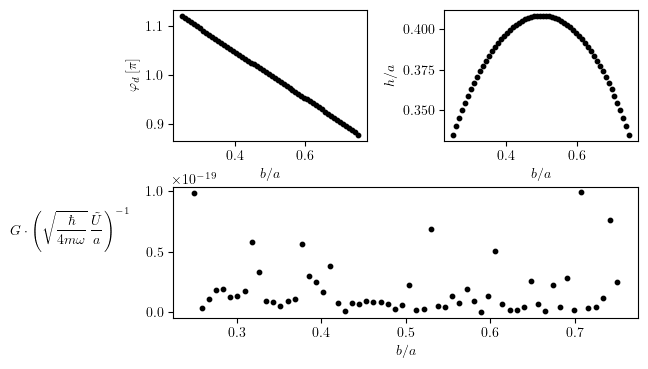

In [201]:
phis_plot = phis_new
hs_plot = hs_new
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=6,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
gs = gridspec.GridSpec(2,2, figure=fig)
ax = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    # dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.lstsq(dmat,beta)[0]
    # dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    # ax3[1].scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    ax3.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)
    # ax2.scatter(b[i],sorted_crit[0][0],color='0',s=10)

ax.scatter(b,phis_plot/np.pi,color='0',s=10)
ax2.scatter(b,hs_plot,color='0',s=10)
ax.set_xlabel(r"$b/a$")
ax.set_ylabel(r"$\varphi_d\,[\pi]$")
ax2.set_xlabel(r"$b/a$")
ax2.set_ylabel(r"$h/a$")
ax3.set_xlabel(r"$b/a$")
ax3.set_ylabel(r"$$G\cdot\left(\sqrt{\frac{\hbar }{4m \omega}}\,\frac{\tilde{U}}{a}\right)^{-1}$$",rotation=0,labelpad=55)
plt.subplots_adjust(wspace=0.4,hspace=0.35)
plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"tuning_first_order_to_zero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
plt.show()

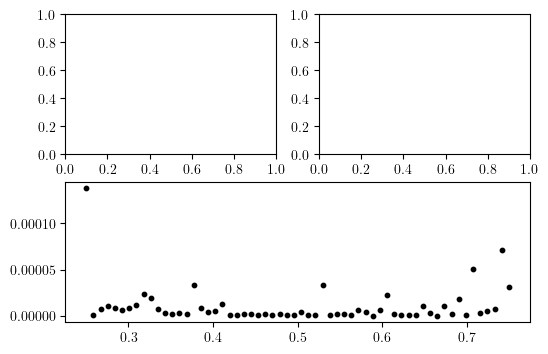

In [202]:
phis_plot = phis_new
hs_plot = hs_new
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=6,fig_height=4,xax_share=True,joined=True)
fig = plt.figure(figsize=(setup.fig_width,setup.fig_height))
gs = gridspec.GridSpec(2,2, figure=fig)
ax = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])
# fig, ax = setup.return_fig((1,2))
# fig2, ax3 = setup.return_fig((1,2))
for i in range(N):
    
    dmat = nearest_nb_Hamiltonian(b[i],hs_plot[i],a,chain_length,lambda x, y: dip_derivative_full(x, 0, 0, y),0,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))

    eig, vec = np.linalg.eig(dmat)
    # ax.scatter(b[i]*np.ones(chain_length),eig,color='0',s=30)
    beta = grad(b[i],hs_plot[i],a,chain_length,nom_der1,np.array([np.cos(phis_plot[i]),np.sin(phis_plot[i])]))
    dmatp = dmat+ np.diag(np.ones(chain_length))*(m*w**2*r**2/V)[-1]/10**8
    dis = np.linalg.solve(dmatp,beta)
    h_new = beta-dmat@dis
    ax3.scatter(b[i],np.max(h_new),color='0',s=10)
    # ax3[1].scatter(b[i]*np.ones(chain_length),beta,color='0',s=30)
    # ax3.scatter(b[i],np.max(h_new)/(np.max(np.abs(dmat))*3/1000),color='0',s=10)

In [93]:
dmat = nearest_nb_Hamiltonian(b[0],h,a,8,lambda x, y: dip_derivative_full(x, 0, 0, y),0,d)
eig, vec = np.linalg.eig(dmat)
np.round(dmat,1), eig

(array([[-1701.3,  1701.3,     0. ,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [ 1701.3, -1678.5,   -22.9,     0. ,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,   -22.9, -1678.5,  1701.3,     0. ,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,  1701.3, -1678.5,   -22.9,     0. ,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,   -22.9, -1678.5,  1701.3,     0. ,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,  1701.3, -1678.5,   -22.9,
             0. ],
        [    0. ,     0. ,     0. ,     0. ,     0. ,   -22.9, -1678.5,
          1701.3],
        [    0. ,     0. ,     0. ,     0. ,     0. ,     0. ,  1701.3,
         -1701.3]]),
 array([ 3.90897870e+01,  2.30072217e+01,  5.36701980e-14,  6.77118539e+00,
        -3.36372729e+03, -3.37996333e+03, -3.40266358e+03, -3.39604590e+03]))

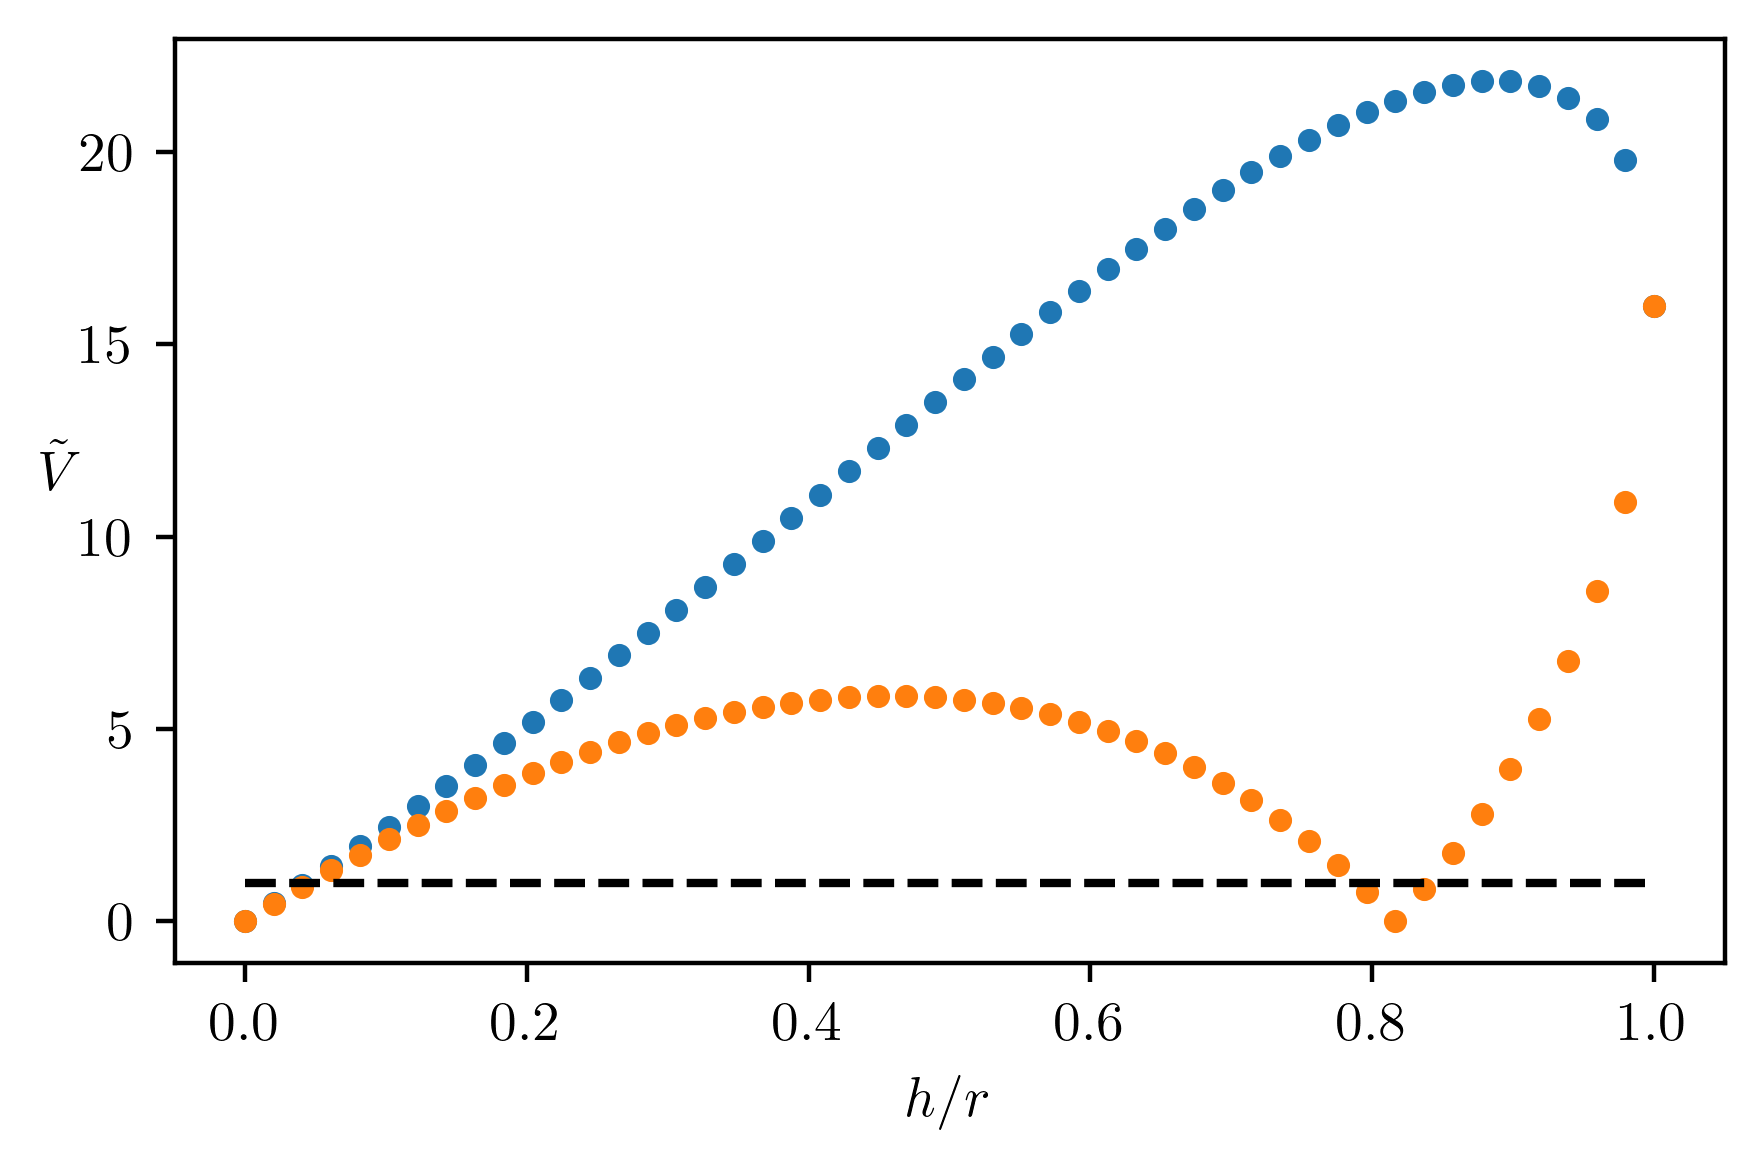

In [12]:
x = np.linspace(0,1)
y1 = -16*(x**2+np.sqrt(2*(1-x**2))*x)
y2 = -16*(x**2-np.sqrt(2*(1-x**2))*x)

setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=5,fig_height=3,xax_share=True,joined=True)

wrapper = [[],[]]
fig, ax = setup.return_fig((1,1))
ax.set_xlabel(r"$h/r$")
ax.set_ylabel(r"$\tilde{V}$",rotation=0)
ax.scatter(x,np.abs(y1),label="-",s=10)
ax.scatter(x,np.abs(y2),label="+",s=10)
ax.hlines(1,x[0],x[-1],linestyle="dashed",color='0')
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_derV_ifVzero.pdf")#free_evol_1spto10coupling

plt.show()

In [13]:

"""
Computes ∂f/∂r_x of the function:
 
    f = (1/r^5) * [-3 + 15*(r·d)²/r² - 6*dx² + 60*dx*rx/r²*(r·d) + 15*(rx/r)²*(1 - 7*(r·d)²/r²)]
 
where r = ||(rx, ry)||, r·d = rx*dx + ry*dy.
"""
 
import sympy as sp
 
# ── Symbols ───────────────────────────────────────────────────────────────────
rx, ry, dx, dy = sp.symbols("r_x r_y d_x d_y", real=True)
 
# ── Derived quantities ────────────────────────────────────────────────────────
r2   = rx**2 + ry**2          # r² (avoids sqrt in denominator until the end)
rdot = rx*dx + ry*dy          # r · d
 
# ── Function f ────────────────────────────────────────────────────────────────
bracket = (
    -3
    + 15 * rdot**2 / r2
    - 6 * dx**2
    + 60 * dx * rx / r2 * rdot
    + 15 * rx**2 / r2 * (1 - 7 * rdot**2 / r2)
)
 
f = bracket / r2**sp.Rational(5, 2)   # 1/r^5 = 1/(r²)^(5/2)
 
# ── Derivative ────────────────────────────────────────────────────────────────
df_drx = sp.simplify(sp.diff(f, rx))
df2_drx2 = sp.simplify(sp.diff(df_drx, rx))

# ── Output ────────────────────────────────────────────────────────────────────
print("∂f/∂r_x =")
sp.pprint(df_drx, use_unicode=True)
print()
print("LaTeX:")
print(sp.latex(df_drx))


ModuleNotFoundError: No module named 'sympy'

/tmp/ipykernel_43745/2634336619.py:7: RuntimeWarning: invalid value encountered in sqrt
  dy = np.sqrt(1-dx**2)
/tmp/ipykernel_43745/2634336619.py:33: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(phi,V/Vder,s=10)


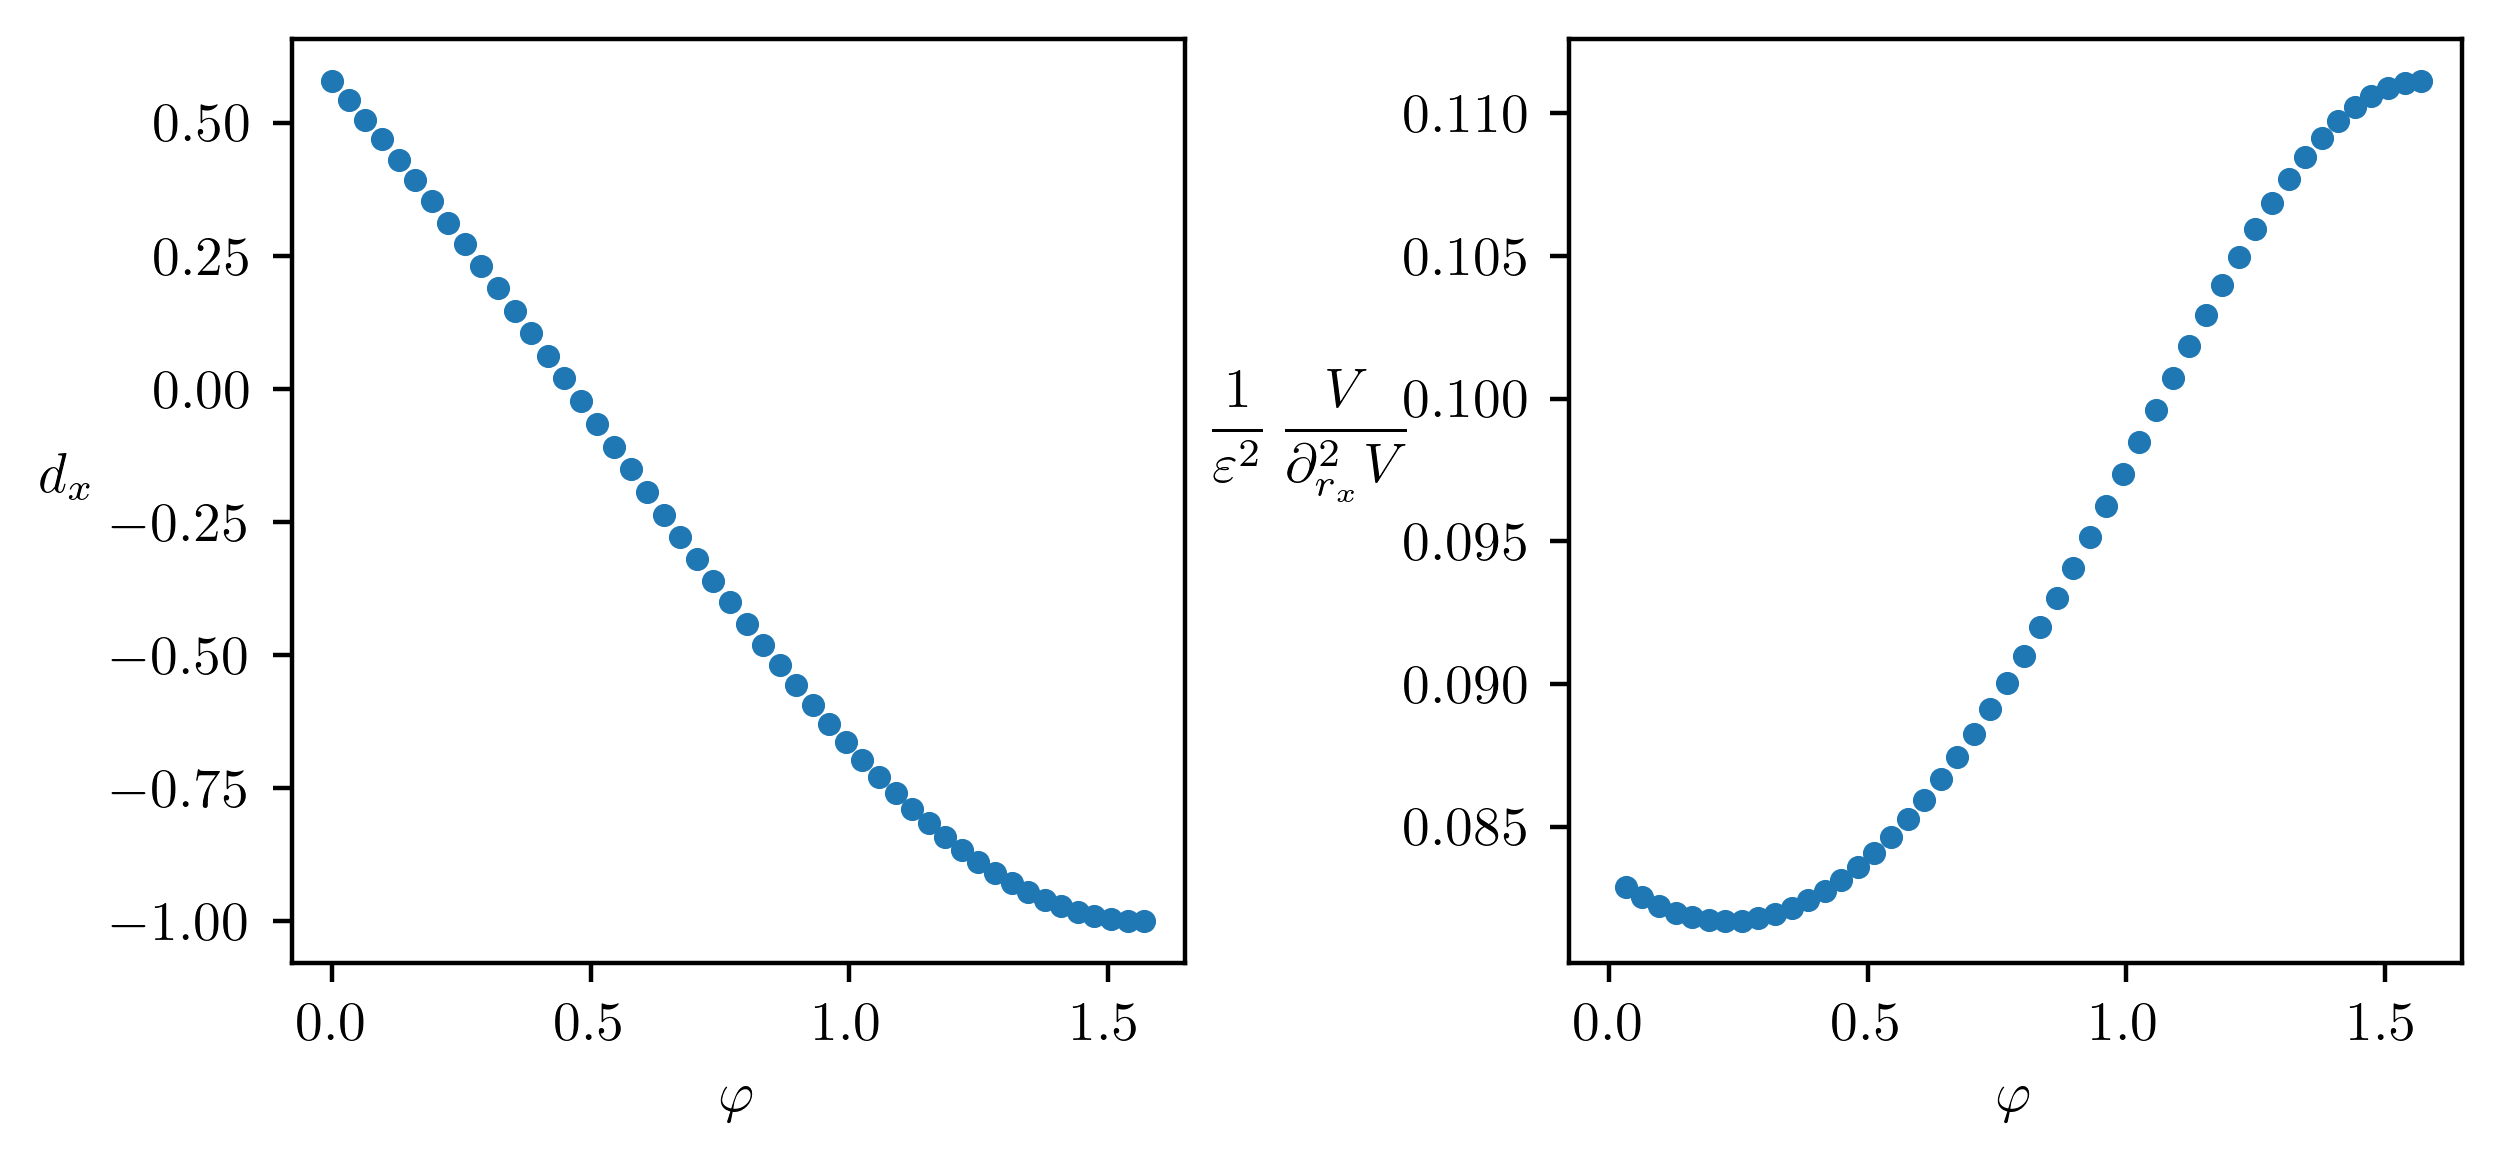

In [ ]:
from scipy.optimize import root_scalar
phi =  np.linspace(0,np.pi/2)

def func(dx,phi):
    rx = np.cos(phi)
    ry = np.sin(phi)
    dy = np.sqrt(1-dx**2)
    f = -3*rx + 15*rx*(rx*dx+ry*dy)**2-6*dx*(rx*dx+ry*dy)
    return f
dip = np.zeros(len(phi))
dip2 = np.zeros(len(phi))
V = np.zeros_like(phi)
Vder = np.zeros_like(phi)
for i in range(len(phi)):
    bracket = (max(-1,0-phi[i]/2*2.8),max(0,0.7-phi[i]/2))
    # bracket = (0,1)
    if func(bracket[0],phi[i])*func(bracket[1],phi[i])<=0:
        root = root_scalar(func,args=phi[i],bracket=bracket)
        # root = root_scalar(func,args=phi[i],x0=0)
        dip[i] = root.root
        Vder[i] = dip_derivative_full(np.array([np.cos(phi[i]),np.sin(phi[i])]),0,0,np.array([dip[i],np.sqrt(1-dip[i]**2)]))
        V[i] = dip_dip(np.array([np.cos(phi[i]),np.sin(phi[i])]),np.array([dip[i],np.sqrt(1-dip[i]**2)]))
    root = root_scalar(func,args=phi[i],x0=0)
    dip2[i] = root.root
setup = Setup_Fig(name_of_plot='lam2_anal_ml.png',fig_width=7,fig_height=3,xax_share=True,joined=True)

fig, ax = setup.return_fig((1,2))
ax[0].scatter(phi,dip,s=10)
# ax.scatter(phi,dip2)
# ax.scatter(phi,np.cos(phi))
# plt.show()
# fig, ax = plt.subplots(1,1)
ax[1].scatter(phi,V/Vder,s=10)
# ax.scatter(phi,V)
# ax.scatter(phi,dip2)
ax[0].set_xlabel(r'$\varphi$')
ax[1].set_xlabel(r'$\varphi$')
ax[0].set_ylabel(r"$d_x$",rotation=0,labelpad=8)
ax[1].set_ylabel(r"$$\frac{1}{\varepsilon^2}\,\frac{V}{\partial_{r_x}^2 V}$$",rotation=0,labelpad=17)
plt.subplots_adjust(wspace=0.43)
# plt.savefig("/home/christian/Documents/master/protocol/pictures/"+"magnitude_dersqV_ifderVzero.pdf",bbox_inches='tight')#free_evol_1spto10coupling
#
plt.show()

In [ ]:
2*np.pi*86*c.u, c.hbar, c.u

(8.9727882246588e-25, 1.0545718176461565e-34, 1.66053906892e-27)